In [2]:
import pandas as pd

In [3]:
spam_df = pd.read_csv("../data/spam.csv", encoding="latin-1")

In [4]:
spam_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
spam_df = spam_df.drop(
    columns=spam_df.columns[spam_df.columns.str.startswith("Unnamed")],
    errors="ignore"
)

In [6]:
spam_df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
spam_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [8]:
spam_df.shape

(5572, 2)

In [9]:
spam_df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [10]:
toxic_df = pd.read_csv("../data/train.csv")

In [11]:
toxic_df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [12]:
toxic_df.shape

(159571, 8)

In [13]:
toxic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [14]:
# checking toxicity labels
toxic_df.iloc[:, 2:].sum().sort_values(ascending=False)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

In [15]:
spam_df = spam_df[["v1", "v2"]].copy()

spam_df.columns = ["label", "text"]

spam_df["label"] = spam_df["label"].map({
    "ham": "clean",
    "spam": "spam"
})

spam_df.head()

,label,text
0,clean,"Go until jurong point, crazy.. Available only ..."
1,clean,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,clean,U dun say so early hor... U c already then say...
4,clean,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# selecting required columns in toxic_df
toxic_df = toxic_df[[ "comment_text", "toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]].copy()

# Creating a single abusive label
toxicity_columns = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

toxic_df["label"] = (toxic_df[toxicity_columns].sum(axis=1) > 0).map({True: "abusive", False: "clean"})

# renaming text column
toxic_df = toxic_df.rename(columns={"comment_text": "text"})

# keeping only required columns
toxic_df = toxic_df[["text", "label"]]

toxic_df.head()

,text,label
0,Explanation\nWhy the edits made under my usern...,clean
1,D'aww! He matches this background colour I'm s...,clean
2,"Hey man, I'm really not trying to edit war. It...",clean
3,"""\nMore\nI can't make any real suggestions on ...",clean
4,"You, sir, are my hero. Any chance you remember...",clean


In [17]:
# combining spam and toxic datasets
combined_df = pd.concat([spam_df, toxic_df], ignore_index=True)
combined_df.head()

,label,text
0,clean,"Go until jurong point, crazy.. Available only ..."
1,clean,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,clean,U dun say so early hor... U c already then say...
4,clean,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165143 entries, 0 to 165142
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   165143 non-null  str  
 1   text    165143 non-null  str  
dtypes: str(2)
memory usage: 2.5 MB


In [19]:
combined_df.shape

(165143, 2)

In [20]:
combined_df["label"].value_counts()

label
clean      148171
abusive     16225
spam          747
Name: count, dtype: int64

In [21]:
# checking missing values
combined_df.isnull().sum()

label    0
text     0
dtype: int64

In [22]:
# checking for duplicate rows
combined_df.duplicated().sum()

np.int64(403)

In [24]:
# Removing rows where text or label is missing
combined_df = combined_df.dropna(subset= ["text", "label"])

# Remving duplicate messages
combined_df = combined_df.drop_duplicates(subset= ["text", "label"]).reset_index(drop=True)

# checking the cleaned dataset
print("Dataset shape", combined_df.shape)

print("\nMissing values:\n", combined_df.isnull().sum())
print("\nDuplicate rows:\n", combined_df.duplicated().sum())

Dataset shape (164740, 2)

Missing values:
 label    0
text     0
dtype: int64

Duplicate rows:
 0


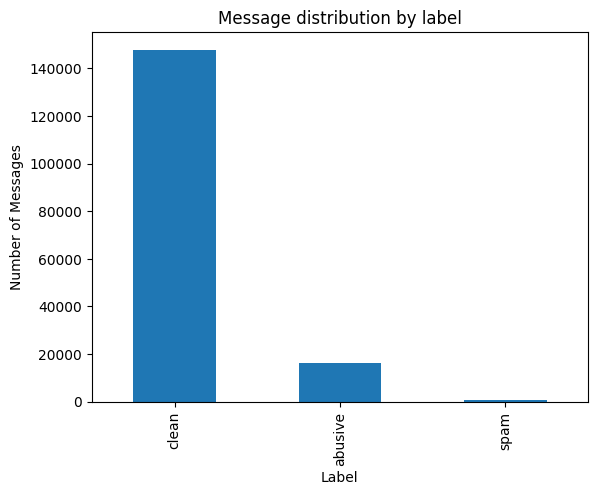

In [26]:
# Visualising the label distribution
import matplotlib.pyplot as plt

label_counts = combined_df["label"].value_counts()

label_counts.plot(kind="bar", title="Message distribution by label")
plt.xlabel("Label")
plt.ylabel("Number of Messages")
plt.show()

In [28]:
# saving cleaned dataset
combined_df.to_csv("../data/cleaned_moderation_data.csv", index=False)